<a href="https://colab.research.google.com/github/nhuhoan050700/violence-detection-brutnet/blob/main/brutnet-violence-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/drive/MyDrive/Data", exist_ok=True)

import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("quangkhanh205/hockeyfight-frame")
print("Dataset path:", path)

Using Colab cache for faster access to the 'hockeyfight-frame' dataset.
Dataset path: /kaggle/input/hockeyfight-frame


In [39]:
IMG_HEIGHT = 90
IMG_WIDTH = 160
SEQUENCE_LENGTH = 24
BATCH_SIZE = 4   # smaller due to Colab RAM

In [40]:
def build_dataset(folder, label):
    folders, labels = [], []
    for v in os.listdir(folder):
        full = os.path.join(folder, v)
        if os.path.isdir(full):
            folders.append(full)
            labels.append(label)
    return folders, labels

train_v_path = os.path.join(path, "Train_Violence")
train_n_path = os.path.join(path, "Train_Non")

test_v_path = os.path.join(path, "Test_Violence")
test_n_path = os.path.join(path, "Test_Non")

train_v_f, train_v_l = build_dataset(train_v_path, 1)
train_n_f, train_n_l = build_dataset(train_n_path, 0)

test_v_f, test_v_l = build_dataset(test_v_path, 1)
test_n_f, test_n_l = build_dataset(test_n_path, 0)

train_folders = train_v_f + train_n_f
train_labels = train_v_l + train_n_l

test_folders = test_v_f + test_n_f
test_labels = test_v_l + test_n_l

In [41]:
train_folders, val_folders, train_labels, val_labels = train_test_split(
    train_folders,
    train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

In [42]:
def sample_frames(frames, num_frames):
    idx = np.linspace(0, len(frames)-1, num_frames).astype(int)
    return [frames[i] for i in idx]

In [43]:
class VideoGenerator(tf.keras.utils.Sequence):

    def __init__(self, folders, labels, batch_size):
        self.folders = folders
        self.labels = labels
        self.batch_size = batch_size
        self.indices = np.arange(len(folders))

    def __len__(self):
        return len(self.folders) // self.batch_size

    def __getitem__(self, idx):

        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []

        for i in batch_idx:
            folder = self.folders[i]
            label = self.labels[i]

            frames = sorted(os.listdir(folder))
            frames = sample_frames(frames, SEQUENCE_LENGTH)

            clip = []

            for f in frames:
                img = cv2.imread(os.path.join(folder, f))
                if img is None:
                    continue

                img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
                img = img / 255.0
                clip.append(img)

            while len(clip) < SEQUENCE_LENGTH:
                clip.append(clip[-1])

            X.append(clip)
            y.append(label)

        return np.array(X, dtype="float32"), np.array(y)

In [44]:
train_gen = VideoGenerator(train_folders, train_labels, BATCH_SIZE)
val_gen   = VideoGenerator(val_folders, val_labels, BATCH_SIZE)
test_gen  = VideoGenerator(test_folders, test_labels, BATCH_SIZE)

In [45]:
def build_brutnet(input_shape):

    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.TimeDistributed(layers.Conv2D(32, (3,3), padding='same', activation='relu'))(inputs)
    x = layers.TimeDistributed(layers.Conv2D(32, (3,3), padding='same', activation='relu'))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D(2,2))(x)

    # Block 2
    x = layers.TimeDistributed(layers.Conv2D(64, (3,3), padding='same', activation='relu'))(x)
    x = layers.TimeDistributed(layers.Conv2D(64, (3,3), padding='same', activation='relu'))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D(2,2))(x)

    # Block 3
    x = layers.TimeDistributed(layers.Conv2D(128, (3,3), padding='same', activation='relu'))(x)
    x = layers.TimeDistributed(layers.Conv2D(128, (3,3), padding='same', activation='relu'))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.MaxPooling2D(2,2))(x)

    # Block 4 (IMPORTANT: only ONE conv here)
    x = layers.TimeDistributed(layers.Conv2D(512, (3,3), padding='same', activation='relu'))(x)

    # Global Max Pool → (512 features per frame)
    x = layers.TimeDistributed(layers.GlobalMaxPooling2D())(x)

    # GRU
    x = layers.GRU(64)(x)

    # Dense layers (match paper EXACT)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs, outputs)

In [46]:
model = build_brutnet((SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3))

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # paper value
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 24, 90, 160, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_60             │ (None, 24, 90, 160,    │           896 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_61             │ (None, 24, 90, 160,    │         9,248 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_62             │ (None, 24, 90, 160,    │           128 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_63             │ (None, 24, 45, 80, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_64             │ (None, 24, 45, 80, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_65             │ (None, 24, 45, 80, 64) │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_66             │ (None, 24, 45, 80, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_67             │ (None, 24, 22, 40, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_68             │ (None, 24, 22, 40,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_69             │ (None, 24, 22, 40,     │       147,584 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_70             │ (None, 24, 22, 40,     │           512 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_71             │ (None, 24, 11, 20,     │             0 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_72             │ (None, 24, 11, 20,     │       590,336 │
│ (TimeDistributed)               │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_73             │ (None, 24, 512)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 64)             │       110,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1024)           │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1024)           │     1,049,60

 Total params: 2,704,161 (10.32 MB)

 Trainable params: 2,703,713 (10.31 MB)

 Non-trainable params: 448 (1.75 KB)

In [47]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

In [48]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Data/best_brutnet_model.h5",
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

In [49]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.5097 - loss: 0.7032
Epoch 1: val_loss improved from None to 0.68563, saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 137s 597ms/step - accuracy: 0.5016 - loss: 0.7023 - val_accuracy: 0.7063 - val_loss: 0.6856
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.5612 - loss: 0.6837
Epoch 2: val_loss improved from 0.68563 to 0.67367, saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 88s 550ms/step - accuracy: 0.5453 - loss: 0.6855 - val_accuracy: 0.8250 - val_loss: 0.6737
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.5798 - loss: 0.6777
Epoch 3: val_loss improved from 0.67367 to 0.60664, saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 88s 546ms/step - accuracy: 0.6031 - loss: 0.6649 - val_accuracy: 0.8438 - val_loss: 0.6066
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.7222 - loss: 0.6045
Epoch 4: val_loss improved from 0.60664 to 0.48922, saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 88s 548ms/step - accuracy: 0.7719 - loss: 0.5796 - val_accuracy: 0.8625 - val_loss: 0.4892
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.8976 - loss: 0.4884
Epoch 5: val_loss improved from 0.48922 to 0.37632, saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 88s 548ms/step - accuracy: 0.8984 - loss: 0.4573 - val_accuracy: 0.8875 - val_loss: 0.3763
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9377 - loss: 0.3569
Epoch 6: val_loss improved from 0.37632 to 0.28457, saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 88s 551ms/step - accuracy: 0.9484 - loss: 0.3178 - val_accuracy: 0.9062 - val_loss: 0.2846
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.9753 - loss: 0.2204
Epoch 7: val_loss improved from 0.28457 to 0.25063, saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 88s 547ms/step - accuracy: 0.9672 - loss: 0.2143 - val_accuracy: 0.9250 - val_loss: 0.2506
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.9846 - loss: 0.1409
Epoch 8: val_loss improved from 0.25063 to 0.22611, saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/Data/best_brutnet_model.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 88s 548ms/step - accuracy: 0.9844 - loss: 0.1368 - val_accuracy: 0.9187 - val_loss: 0.2261
Epoch 9/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.9899 - loss: 0.1126
Epoch 9: val_loss did not improve from 0.22611
160/160 ━━━━━━━━━━━━━━━━━━━━ 87s 539ms/step - accuracy: 0.9875 - loss: 0.1061 - val_accuracy: 0.9250 - val_loss: 0.2431
Epoch 10/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9956 - loss: 0.0559
Epoch 10: val_loss did not improve from 0.22611
160/160 ━━━━━━━━━━━━━━━━━━━━ 87s 542ms/step - accuracy: 0.9875 - loss: 0.0759 - val_accuracy: 0.9250 - val_loss: 0.2578
Epoch 11/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9854 - loss: 0.0562
Epoch 11: val_loss did not improve from 0.22611
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 540ms/step - accuracy: 0.9875 - loss: 0.0545 - val_accuracy: 0.9312 - val_loss: 0.2457
Epoch 12/50
160/160 ━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

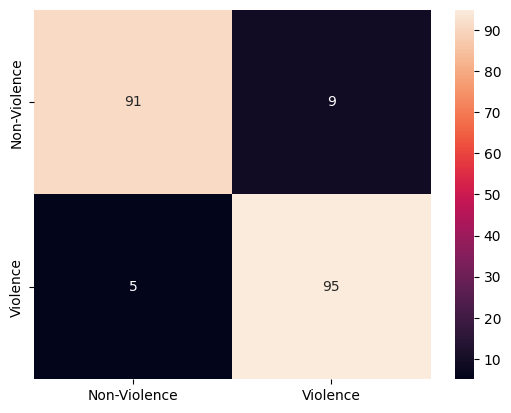

In [50]:
y_true, y_pred = [], []

for X_batch, y_batch in test_gen:
    preds = model.predict(X_batch)
    preds = (preds > 0.5).astype(int)

    y_true.extend(y_batch)
    y_pred.extend(preds.flatten())

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Non-Violence','Violence'],
            yticklabels=['Non-Violence','Violence'])

plt.show()